In [1]:
using MLDatasets

In [2]:
using ImageShow

In [3]:
using MLDatasets: MNIST

In [4]:
?MNIST

search: MNIST EMNIST



```julia
MNIST(; Tx=Float32, split=:train, dir=nothing)
MNIST([Tx, split])
```

The MNIST database of handwritten digits.

  * Authors: Yann LeCun, Corinna Cortes, Christopher J.C. Burges
  * Website: http://yann.lecun.com/exdb/mnist/

MNIST is a classic image-classification dataset that is often used in small-scale machine learning experiments. It contains 70,000 images of handwritten digits. Each observation is a 28x28 pixel gray-scale image that depicts a handwritten version of 1 of the 10 possible digits (0-9).

# Arguments

  * You can pass a specific `dir` where to load or download the dataset, otherwise uses the default one.
  * `split`: selects the data partition. Can take the values `:train` or `:test`.

# Fields

  * `metadata`: A dictionary containing additional information on the dataset.
  * `features`: An array storing the data features.
  * `targets`: An array storing the targets for supervised learning.
  * `split`.

# Methods

  * `dataset[i]`: Return observation(s) `i` as a named tuple of features and targets.
  * `dataset[:]`: Return all observations as a named tuple of features and targets.
  * `length(dataset)`: Number of observations.
  * [`convert2image`](@ref) converts features to `Gray` images.

# Examples

The images are loaded as a multi-dimensional array of eltype `Tx`. If `Tx <: Integer`, then all values will be within `0` and `255`,  otherwise the values are scaled to be between `0` and `1`. `MNIST().features` is a 3D array (i.e. a `Array{Tx,3}`), in WHN format (width, height, num_images). Labels are stored as a vector of integers in `MNIST().targets`. 

```julia-repl
julia> using MLDatasets: MNIST

julia> dataset = MNIST(:train)
MNIST:
  metadata    =>    Dict{String, Any} with 3 entries
  split       =>    :train
  features    =>    28×28×60000 Array{Float32, 3}
  targets     =>    60000-element Vector{Int64}

julia> dataset[1:5].targets
5-element Vector{Int64}:
7
2
1
0
4

julia> X, y = dataset[:];

julia> dataset = MNIST(UInt8, :test)
MNIST:
  metadata    =>    Dict{String, Any} with 3 entries
  split       =>    :test
  features    =>    28×28×10000 Array{UInt8, 3}
  targets     =>    10000-element Vector{Int64}
```


In [5]:
image1 = MNIST(split=:train).features[:,:,1]

28×28 Matrix{Float32}:
 0.0  0.0  0.0  0.0  0.0  0.0        …  0.0       0.0        0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0           0.0       0.0        0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0           0.0       0.0        0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0           0.0       0.0        0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0           0.215686  0.533333   0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0        …  0.67451   0.992157   0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0           0.886275  0.992157   0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0           0.992157  0.992157   0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0           0.992157  0.831373   0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0           0.992157  0.529412   0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0        …  0.992157  0.517647   0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0           0.956863  0.0627451  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0117647     0.521569  0.0        0.0  0.0  0.0
 ⋮

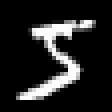

In [6]:
A = MLDatasets.convert2image(MNIST, image1)

We can check that this image corresponds to the number 5.

In [7]:
MNIST(split=:train).targets[1]

5

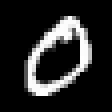

In [8]:
image2 = MNIST(split=:train).features[:,:,2];
MLDatasets.convert2image(MNIST, image2)

In [9]:
MNIST(split=:train).targets[2]

0

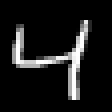

In [10]:
image3 = MNIST(split=:train).features[:,:,3];
MLDatasets.convert2image(MNIST, image3)

In [11]:
MNIST(split=:train).targets[3]

4

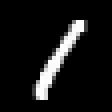

In [12]:
image4 = MNIST(split=:train).features[:,:,4];
MLDatasets.convert2image(MNIST, image4)

In [13]:
MNIST(split=:train).targets[4]

1

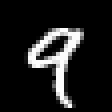

In [14]:
image5 = MNIST(split=:train).features[:,:,5];
MLDatasets.convert2image(MNIST, image5)

In [15]:
MNIST(split=:train).targets[5]

9

## 1. The Labels

The MNIST.trainlabels(i) returns the number that corresponds to the i-th image.

In [16]:
using Flux: onehotbatch

With ``onehotbatch``, each trainlabel is converted to a vector in a matrix.  As MNIST.trainlabel(i) returns an integer in between 0 and 9, the vector that corresponds to the label will have length 10.   The vector will be zero, except for a one at the entry the corresponds to the value of the label.

In [17]:
labels = onehotbatch(MNIST(split=:train).targets, 0:9)

10×60000 OneHotMatrix(::Vector{UInt32}) with eltype Bool:
 ⋅  1  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  …  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅
 ⋅  ⋅  ⋅  1  ⋅  ⋅  1  ⋅  1  ⋅  ⋅  ⋅  ⋅     ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  1  ⋅  ⋅  ⋅  ⋅  ⋅
 ⋅  ⋅  ⋅  ⋅  ⋅  1  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅     ⋅  ⋅  ⋅  1  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅
 ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  1  ⋅  ⋅  1  ⋅  1     ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  1  ⋅  ⋅  ⋅
 ⋅  ⋅  1  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  1  ⋅  ⋅  ⋅     ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅
 1  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  1  ⋅  …  ⋅  ⋅  ⋅  ⋅  ⋅  1  ⋅  ⋅  ⋅  1  ⋅  ⋅
 ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅     ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  1  ⋅
 ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅     1  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅
 ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅     ⋅  1  ⋅  ⋅  ⋅  ⋅  ⋅  1  ⋅  ⋅  ⋅  1
 ⋅  ⋅  ⋅  ⋅  1  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅     ⋅  ⋅  1  ⋅  1  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅  ⋅

The first image corresponds to the number 5.  Consider the first column in the labels.

In [18]:
labels[:,1]

10-element OneHotVector(::UInt32) with eltype Bool:
 ⋅
 ⋅
 ⋅
 ⋅
 ⋅
 1
 ⋅
 ⋅
 ⋅
 ⋅

In [19]:
labels[:,1][6]

true

## 2. The Images as Floating-point vectors

In [20]:
size(image1)

(28, 28)

The images are 28-by-28 matrices.  But our model will take on input a vector.  So we reshape.

In [21]:
image1reshaped = reshape(image1,:);
println(28*28, " reshaped into ", size(image1reshaped))
typeof(image1reshaped)

784 reshaped into (784,)


Vector{Float32} (alias for Array{Float32, 1})

The type of the elements in the array should be floating point.

In [22]:
image1numbers = [Float64(x) for x in image1reshaped];
typeof(image1numbers)

Vector{Float64} (alias for Array{Float64, 1})

Let us do this now on the first ``NBR`` images.

In [23]:
NBR = 100

100

In [24]:
images = Matrix{Float32}(zeros(28*28, NBR));

In [25]:
for i=1:size(images,2)
    image = MNIST(split=:train).features[:,:,i]
    imagereshaped = reshape(image,:)
    imagenumbers = [Float32(x) for x in imagereshaped]
    for j=1:size(images,1)
        images[j, i] = imagenumbers[j]
    end
end

## 3. The Model

In [26]:
using Flux

In [27]:
model = Chain(Dense(28*28,40, relu),Dense(40, 10),softmax)

Chain(
  Dense(784 => 40, relu),               # 31_400 parameters
  Dense(40 => 10),                      # 410 parameters
  NNlib.softmax,
)                   # Total: 4 arrays, 31_810 parameters, 124.461 KiB.

In [28]:
model(images[:,10])

10-element Vector{Float32}:
 0.06112545
 0.094558604
 0.09254761
 0.053480245
 0.10421895
 0.12479073
 0.2020858
 0.072023
 0.12828258
 0.06688702

## 4. The loss function

In [29]:
using Flux: crossentropy
loss(model, X, y) = crossentropy(model(X), y) 

loss (generic function with 1 method)

In [30]:
loss(model, images[:,1], labels[:,1])

2.0499165f0

## 5. Setting the Optimizer

In [31]:
opt = Flux.setup(Adam(), model)

(layers = ((weight = Leaf(Adam(eta=0.001, beta=(0.9, 0.999), epsilon=1.0e-8), (Float32[0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], Float32[0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], (0.9, 0.999))), bias = Leaf(Adam(eta=0.001, beta=(0.9, 0.999), epsilon=1.0e-8), (Float32[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], Float32[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], (0.9, 0.999))), σ = ()), (weight = Leaf(Adam(eta=0.001, beta=(0.9, 0.999), epsilon=1.0e-8), (Float32[0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], Float32[0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0; … ; 0.0 0.0 … 0.0 0.0; 0.0 0.0 … 0.0 0.0], (0.9, 0.999))), bias = Leaf(Adam(eta=0.001, beta=(0.9, 0.999), epsilon=1.0e-8), (Float32[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], Float32[0.0, 0.0, 0.0, 0.0,

## 6. Train the Network

In [32]:
progress = () -> @show(loss(images, labels[:,1:NBR])) # callback to show loss

#8 (generic function with 1 method)

In [33]:
using Flux: throttle

In [34]:
# for epoch in 1:100
#    Flux.train!(loss, model,[(images,labels[:,1:NBR])],
#                opt, cb = throttle(progress, 10))
# end

In [35]:
Flux.train!(loss, model, [(images,labels[:,1:NBR])], opt)

In [36]:
M1 = model(images[:,1])
println("output of the model :\n", M1)
println("the number is ", argmax(M1)-1)

output of the model :
Float32[0.07523438, 0.102341086, 0.04478638, 0.0643297, 0.061130673, 0.12858509, 0.16505046, 0.061277054, 0.20731474, 0.08995051]
the number is 8


In [37]:
M2 = model(images[:,2])
println("output of the model :\n", M2)
println("the number is ", argmax(M2)-1)

output of the model :
Float32[0.07411358, 0.07917319, 0.04280753, 0.084249966, 0.05826421, 0.13115151, 0.21538919, 0.08119454, 0.14372681, 0.08992948]
the number is 6


In [38]:
M3 = model(images[:,3])
println("output of the model :\n", M3)
println("the number is ", argmax(M3)-1)

output of the model :
Float32[0.071522586, 0.097622626, 0.09464613, 0.087033644, 0.09512037, 0.096759036, 0.111089736, 0.11692335, 0.14441869, 0.08486382]
the number is 8


In [39]:
M4 = model(images[:,4])
println("output of the model :\n", M4)
println("the number is ", argmax(M4)-1)

output of the model :
Float32[0.087359436, 0.10125624, 0.0784128, 0.07464189, 0.120337285, 0.13014357, 0.14654939, 0.078298345, 0.1029652, 0.080035836]
the number is 6


In [40]:
M5 = model(images[:,5])
println("output of the model :\n", M5)
println("the number is ", argmax(M5)-1)

output of the model :
Float32[0.049236123, 0.08497084, 0.060070373, 0.062002707, 0.060062055, 0.12337599, 0.28734037, 0.06564272, 0.12743157, 0.07986726]
the number is 6


We see that our model has recognized the first 5 images correctly.

In [41]:
idx = rand((1:NBR),1)

1-element Vector{Int64}:
 47

In [42]:
Midx = model(images[:,idx[1]])
println("output of the model :\n", Midx)
println("the number is ", argmax(Midx)-1)
println("label : ", MNIST(split=:train).targets[idx])

output of the model :
Float32[0.07772189, 0.1026425, 0.09915342, 0.063086785, 0.088575475, 0.11799168, 0.17290437, 0.062971756, 0.12266865, 0.09228349]
the number is 6
label : [8]
